In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 20 MW PEM GREEN HYDROGEN TECHNO-ECONOMIC & LCOH VALUATION
Nameplate Power Capacity:        20.0 MWe
Total Initial CAPEX:             €22,000,000.00 (€1100/kW)
Annual Full Load Hours (FLH):    8,556 h / 8,760 h
Annual Green H2 Output:          3,259.4 Metric Tons / yr
Average Electricity Cost Incurred: €48.30 / MWh
---------------------------------------------------------------------------
Levelized Cost of Hydrogen (LCOH): €3.51 / kg H2
  • Electricity Procurement Share: €2.54 / kg (72.2%)
  • Initial CAPEX Amortization:    €0.64 / kg (18.1%)
  • Fixed OPEX & Maintenance:      €0.20 / kg (5.8%)
  • Stack Replacement (Year 8):    €0.11 / kg (3.2%)
  • Water & Demineralization:      €0.03 / kg (0.7%)


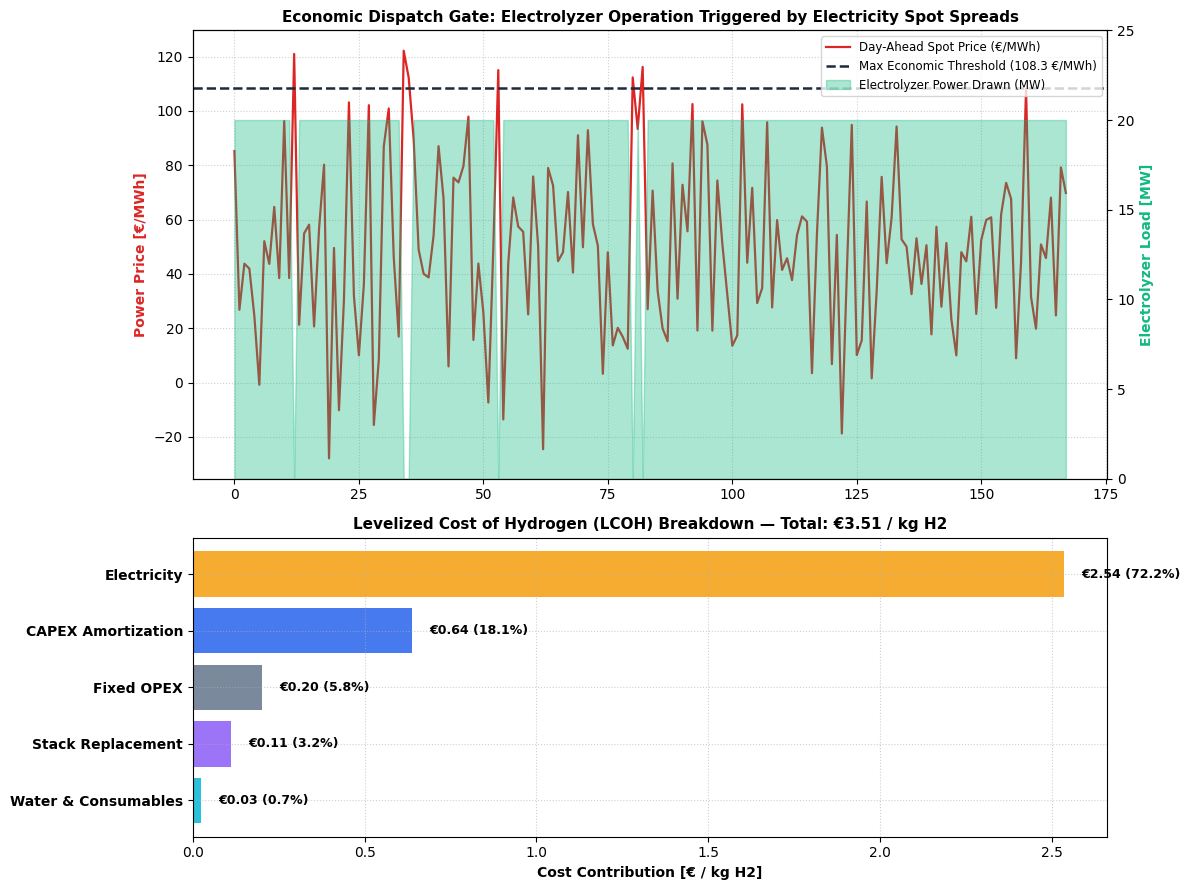

Data exported successfully.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. 8760-HOUR ELECTROLYZER DISPATCH & TECHNO-ECONOMICS
# ==========================================================
np.random.seed(42)
HOURS = 8760
hours_arr = np.arange(HOURS)

# Technical Parameters (PEM Electrolyzer)
ELECTROLYZER_CAPACITY_MWE = 20.0       # 20 MW Electrical Capacity
SPECIFIC_CONSUMPTION_KWH_KG = 52.5    # kWh electricity per kg H2 (~64% LHV efficiency)
WATER_CONSUMPTION_L_KG = 10.0         # Liters of demineralized water per kg H2
WATER_COST_EUR_M3 = 2.50              # Water cost: €2.50 / m³ (€0.0025 / L)
MIN_LOAD_FRACTION = 0.10              # 10% minimum operating load (turndown)

# Financial & Regulatory CAPEX/OPEX Assumptions
CAPEX_EUR_PER_KW = 1100.0             # €1,100 / kWe installed
TOTAL_CAPEX_EUR = ELECTROLYZER_CAPACITY_MWE * 1000 * CAPEX_EUR_PER_KW  # €22,000,000
OPEX_FIXED_PCT_CAPEX = 0.03           # 3% of CAPEX per year (Maintenance, Insurance, Staff)
ANNUAL_FIXED_OPEX_EUR = TOTAL_CAPEX_EUR * OPEX_FIXED_PCT_CAPEX
STACK_REPLACEMENT_YEAR = 8            # Stack replacement at year 8
STACK_REPLACEMENT_COST_EUR = 0.30 * TOTAL_CAPEX_EUR
WACC = 0.07                           # 7.0% Discount Rate (Weighted Average Cost of Capital)
PROJECT_LIFETIME_YEARS = 20           # 20-Year Economic Asset Life

# Market & Offtake Conditions
H2_OFFTAKE_PRICE_EUR_KG = 6.50        # Industrial offtake contract price (€/kg)
GRID_FEES_TAXES_EUR_MWH = 15.0        # Residual grid fees/levies (assuming partial EEG exemption)

# 8760-Hour Synthetic Spot Price Curve (EPEX Spot Profile with volatility & negative hours)
base_spot = 45.0 + 25.0 * np.sin(2 * np.pi * hours_arr / 8760)
daily_cycle = 20.0 * np.sin(2 * np.pi * (hours_arr % 24 - 6) / 24)
volatility = np.random.normal(0, 30.0, HOURS)
solar_suppression = np.where((hours_arr % 24 >= 10) & (hours_arr % 24 <= 16), -35.0, 0.0)

spot_prices_eur_mwh = np.clip(base_spot + daily_cycle + volatility + solar_suppression, -30.0, 250.0)
effective_power_price_eur_mwh = spot_prices_eur_mwh + GRID_FEES_TAXES_EUR_MWH

# Economic Dispatch Optimization Logic:
# Maximum breakeven power price = (H2_Offtake_Price - Variable_Water_Cost) / (Specific_Consumption / 1000)
var_water_cost_per_kg = (WATER_CONSUMPTION_L_KG / 1000.0) * WATER_COST_EUR_M3
max_willingness_to_pay_eur_mwh = (H2_OFFTAKE_PRICE_EUR_KG - var_water_cost_per_kg) / (SPECIFIC_CONSUMPTION_KWH_KG / 1000.0)

# Dispatch decision: Operate at full load if effective electricity cost < willingness-to-pay
is_operating = effective_power_price_eur_mwh <= max_willingness_to_pay_eur_mwh
power_drawn_mw = np.where(is_operating, ELECTROLYZER_CAPACITY_MWE, 0.0)
hourly_h2_produced_kg = np.where(is_operating, (ELECTROLYZER_CAPACITY_MWE * 1000.0) / SPECIFIC_CONSUMPTION_KWH_KG, 0.0)
hourly_power_cost_eur = power_drawn_mw * effective_power_price_eur_mwh
hourly_water_cost_eur = hourly_h2_produced_kg * var_water_cost_per_kg

# Annual Operational Metrics
annual_operating_hours = np.sum(is_operating)
annual_h2_production_kg = np.sum(hourly_h2_produced_kg)
annual_power_consumed_mwh = np.sum(power_drawn_mw)
annual_electricity_cost_eur = np.sum(hourly_power_cost_eur)
annual_water_cost_eur = np.sum(hourly_water_cost_eur)
annual_variable_opex_eur = annual_electricity_cost_eur + annual_water_cost_eur
avg_procured_power_price = annual_electricity_cost_eur / annual_power_consumed_mwh if annual_power_consumed_mwh > 0 else 0.0

# ==========================================================
# 2. DISCOUNTED CASH FLOW (DCF) & LCOH CALCULATION
# ==========================================================
discount_factors = np.array([(1 + WACC) ** (-t) for t in range(PROJECT_LIFETIME_YEARS + 1)])

# Cash Outflows Vector (Year 0 to 20)
cash_outflows = np.zeros(PROJECT_LIFETIME_YEARS + 1)
cash_outflows[0] = TOTAL_CAPEX_EUR
for yr in range(1, PROJECT_LIFETIME_YEARS + 1):
    annual_total_opex = ANNUAL_FIXED_OPEX_EUR + annual_variable_opex_eur
    if yr == STACK_REPLACEMENT_YEAR:
        annual_total_opex += STACK_REPLACEMENT_COST_EUR
    cash_outflows[yr] = annual_total_opex

# Discounted Lifetime H2 Production Vector
discounted_h2_kg_vector = np.zeros(PROJECT_LIFETIME_YEARS + 1)
for yr in range(1, PROJECT_LIFETIME_YEARS + 1):
    discounted_h2_kg_vector[yr] = annual_h2_production_kg

# LCOH Formula: Total Discounted Lifetime Costs / Total Discounted Lifetime Production
npv_total_costs = np.sum(cash_outflows * discount_factors)
npv_lifetime_h2_kg = np.sum(discounted_h2_kg_vector * discount_factors)
lcoh_eur_per_kg = npv_total_costs / npv_lifetime_h2_kg

# LCOH Component Breakdown (€/kg)
crf = (WACC * (1 + WACC) ** PROJECT_LIFETIME_YEARS) / (((1 + WACC) ** PROJECT_LIFETIME_YEARS) - 1)
annualized_capex = TOTAL_CAPEX_EUR * crf
lcoh_capex_share = annualized_capex / annual_h2_production_kg
lcoh_elec_share = annual_electricity_cost_eur / annual_h2_production_kg
lcoh_fixed_opex_share = ANNUAL_FIXED_OPEX_EUR / annual_h2_production_kg
lcoh_stack_share = (STACK_REPLACEMENT_COST_EUR * ((1 + WACC) ** (-STACK_REPLACEMENT_YEAR)) * crf) / annual_h2_production_kg
lcoh_water_other_share = lcoh_eur_per_kg - (lcoh_capex_share + lcoh_elec_share + lcoh_fixed_opex_share + lcoh_stack_share)

# ==========================================================
# 3. CONSOLE OUTPUT SUMMARY
# ==========================================================
print("=" * 75)
print(" 20 MW PEM GREEN HYDROGEN TECHNO-ECONOMIC & LCOH VALUATION")
print("=" * 75)
print(f"Nameplate Power Capacity:        {ELECTROLYZER_CAPACITY_MWE:.1f} MWe")
print(f"Total Initial CAPEX:             €{TOTAL_CAPEX_EUR:,.2f} (€{CAPEX_EUR_PER_KW:.0f}/kW)")
print(f"Annual Full Load Hours (FLH):    {annual_operating_hours:,} h / 8,760 h")
print(f"Annual Green H2 Output:          {annual_h2_production_kg / 1000:,.1f} Metric Tons / yr")
print(f"Average Electricity Cost Incurred: €{avg_procured_power_price:.2f} / MWh")
print("-" * 75)
print(f"Levelized Cost of Hydrogen (LCOH): €{lcoh_eur_per_kg:.2f} / kg H2")
print(f"  • Electricity Procurement Share: €{lcoh_elec_share:.2f} / kg ({lcoh_elec_share/lcoh_eur_per_kg*100:.1f}%)")
print(f"  • Initial CAPEX Amortization:    €{lcoh_capex_share:.2f} / kg ({lcoh_capex_share/lcoh_eur_per_kg*100:.1f}%)")
print(f"  • Fixed OPEX & Maintenance:      €{lcoh_fixed_opex_share:.2f} / kg ({lcoh_fixed_opex_share/lcoh_eur_per_kg*100:.1f}%)")
print(f"  • Stack Replacement (Year {STACK_REPLACEMENT_YEAR}):    €{lcoh_stack_share:.2f} / kg ({lcoh_stack_share/lcoh_eur_per_kg*100:.1f}%)")
print(f"  • Water & Demineralization:      €{lcoh_water_other_share:.2f} / kg ({lcoh_water_other_share/lcoh_eur_per_kg*100:.1f}%)")
print("=" * 75)

# ==========================================================
# 4. VISUALIZATION & ARTIFACT EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [1.8, 1.2]})

# Plot 1: 168-Hour Dispatch Dynamics (Sample Week in Summer with High Solar Dip)
sample_hours = hours_arr[3500:3668]
sample_idx = np.arange(168)
ax1.plot(sample_idx, spot_prices_eur_mwh[3500:3668], color="#DC2626", lw=1.6, label="Day-Ahead Spot Price (€/MWh)")
ax1.axhline(max_willingness_to_pay_eur_mwh - GRID_FEES_TAXES_EUR_MWH, color="#1E293B", linestyle="--", lw=1.8, label=f"Max Economic Threshold ({max_willingness_to_pay_eur_mwh - GRID_FEES_TAXES_EUR_MWH:.1f} €/MWh)")
ax1.set_ylabel("Power Price [€/MWh]", fontweight="bold", color="#DC2626")
ax1.set_title("Economic Dispatch Gate: Electrolyzer Operation Triggered by Electricity Spot Spreads", fontsize=11, fontweight="bold")
ax1.grid(True, linestyle=":", alpha=0.6)

ax1_twin = ax1.twinx()
ax1_twin.fill_between(sample_idx, 0, power_drawn_mw[3500:3668], color="#10B981", alpha=0.35, label="Electrolyzer Power Drawn (MW)")
ax1_twin.set_ylabel("Electrolyzer Load [MW]", fontweight="bold", color="#10B981")
ax1_twin.set_ylim(0, 25)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True, fontsize=8.5)

# Plot 2: LCOH Cost Breakdown Horizontal Waterfall Bar
categories = ["Electricity", "CAPEX Amortization", "Fixed OPEX", "Stack Replacement", "Water & Consumables"]
shares = [lcoh_elec_share, lcoh_capex_share, lcoh_fixed_opex_share, lcoh_stack_share, lcoh_water_other_share]
colors = ["#F59E0B", "#2563EB", "#64748B", "#8B5CF6", "#06B6D4"]

y_pos = np.arange(len(categories))
bars = ax2.barh(y_pos, shares, color=colors, alpha=0.85)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(categories, fontweight="bold")
ax2.invert_yaxis()
ax2.set_xlabel("Cost Contribution [€ / kg H2]", fontweight="bold")
ax2.set_title(f"Levelized Cost of Hydrogen (LCOH) Breakdown — Total: €{lcoh_eur_per_kg:.2f} / kg H2", fontsize=11, fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)

for bar in bars:
    width = bar.get_width()
    ax2.text(width + 0.05, bar.get_y() + bar.get_height()/2, f"€{width:.2f} ({(width/lcoh_eur_per_kg)*100:.1f}%)",
             va='center', ha='left', fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("green_hydrogen_lcoh_valuation_model.png", dpi=300)
plt.show()

# Export Dispatch & LCOH Artifacts
df_annual_summary = pd.DataFrame({
    "Cost_Component": categories,
    "LCOH_EUR_per_KG": np.round(shares, 3),
    "Share_Percentage": np.round(np.array(shares) / lcoh_eur_per_kg * 100, 1)
})
df_annual_summary.to_csv("lcoh_component_breakdown.csv", index=False)
print("Data exported successfully.")